Enable GPU

(Runtime → Change runtime type → T4 GPU → Save.)

In [80]:
import torch
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print Tesla T4

False


AssertionError: Torch not compiled with CUDA enabled

Install dependencies

In [81]:
!pip install torch torchvision numpy matplotlib scipy -q

In [82]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [83]:
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

PyTorch version: 2.9.0+cpu
NumPy version: 2.0.2


 Get the Human3.6M preprocessed data

 (Use the preprocessed version from the HumanMAC repository. This avoids dealing with the original Human3.6M registration process, which takes days to get approved)

clone the HumanMAC repo to use their data loader, which is already written and tested:

In [84]:
!git clone https://github.com/LinghaoChan/HumanMAC.git

Cloning into 'HumanMAC'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 133 (delta 24), reused 21 (delta 21), pack-reused 103 (from 1)
Receiving objects: 100% (133/133), 7.86 MiB | 39.85 MiB/s, done.
Resolving deltas: 100% (50/50), done.


In [85]:
%cd HumanMAC

/content/HumanMAC/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/HumanMAC


In [86]:
!ls -F

cfg/	      demos/	  LICENSE  motion-retargeting/	utils/
config.py     doc-CN/	  main.py  README.md
data_loader/  install.sh  models/  requirement.txt


In [87]:
with open('requirement.txt', 'r') as f:
    print(f.read())

matplotlib==3.4.2
numpy==1.21.0
opencv_python==4.2.0.34
pandas==1.0.3
PyYAML==6.0
scipy==1.4.1
tensorflow
tensorboardX==2.6
tqdm==4.46.0
vpython==7.6.4


In [88]:
# Install only what you need for data loading and visualization
!pip install numpy scipy matplotlib tqdm PyYAML -q

In [89]:
import numpy as np
import scipy
import matplotlib
import tqdm
import yaml

print(f"numpy:      {np.__version__}")
print(f"scipy:      {scipy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print("All imports successful.")

numpy:      2.0.2
scipy:      1.16.3
matplotlib: 3.10.0
All imports successful.


In [90]:
# Install PyTorch separately (the right way for Colab)
# Colab already has PyTorch pre-installed. Just verify:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"GPU:             {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch version: 2.9.0+cpu
CUDA available:  False
GPU:             None


In [91]:
# Mounting Drive:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
import os
os.makedirs('data', exist_ok=True)

In [93]:
!cp /content/drive/MyDrive/Datasets/data_3d_h36m.npz data/
!cp /content/drive/MyDrive/Datasets/data_3d_h36m_test.npz data/

In [94]:
import numpy as np

# Load the training data
train_data = np.load('data/data_3d_h36m.npz', allow_pickle=True)

print("=== TRAIN FILE ===")
print(f"Keys: {list(train_data.keys())}")
print(f"Number of keys: {len(train_data.keys())}")

# Look at first key in detail
first_key = list(train_data.keys())[0]
first_val = train_data[first_key]
print(f"\nFirst key: '{first_key}'")
print(f"Type: {type(first_val)}")

# Handle both array and dict formats
if isinstance(first_val, np.ndarray):
    print(f"Shape: {first_val.shape}")
    print(f"Dtype: {first_val.dtype}")
elif hasattr(first_val, 'item'):
    # Numpy object array wrapping a dict
    inner = first_val.item()
    print(f"Inner type: {type(inner)}")
    if isinstance(inner, dict):
        print(f"Inner keys: {list(inner.keys())[:5]}")
        first_inner_key = list(inner.keys())[0]
        print(f"First inner value shape: {inner[first_inner_key].shape}")

=== TRAIN FILE ===
Keys: ['positions_3d']
Number of keys: 1

First key: 'positions_3d'
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: object


The shape () means it's a 0-dimensional numpy array wrapping a Python dictionary inside. This is a common saving pattern. Let's unwrap it and see the actual structure.

In [95]:
# Unwrap the object array
positions_3d = train_data['positions_3d'].item()

print(f"Type after unwrap: {type(positions_3d)}")
print(f"Top-level keys (subjects): {list(positions_3d.keys())}")

Type after unwrap: <class 'dict'>
Top-level keys (subjects): ['S1', 'S5', 'S6', 'S7', 'S8', 'S9', 'S11']


In [96]:
# Drill one level deeper - pick first subject
first_subject = list(positions_3d.keys())[0]
subject_data = positions_3d[first_subject]

print(f"\nSubject: '{first_subject}'")
print(f"Type: {type(subject_data)}")
print(f"Actions available: {list(subject_data.keys())}")


Subject: 'S1'
Type: <class 'dict'>
Actions available: ['Directions 1', 'Directions', 'Discussion 1', 'Discussion', 'Eating 2', 'Eating', 'Greeting 1', 'Greeting', 'Phoning 1', 'Phoning', 'Posing 1', 'Posing', 'Purchases 1', 'Purchases', 'Sitting 1', 'Sitting 2', 'SittingDown 2', 'SittingDown', 'Smoking 1', 'Smoking', 'Photo 1', 'Photo', 'Waiting 1', 'Waiting', 'Walking 1', 'Walking', 'WalkDog 1', 'WalkDog', 'WalkTogether 1', 'WalkTogether']


In [97]:
# Drill into first action
first_action = list(subject_data.keys())[0]
action_data = subject_data[first_action]

print(f"\nAction: '{first_action}'")
print(f"Type: {type(action_data)}")
print(f"Shape: {action_data.shape}")
print(f"Dtype: {action_data.dtype}")
print(f"Min value: {action_data.min():.4f}")
print(f"Max value: {action_data.max():.4f}")


Action: 'Directions 1'
Type: <class 'numpy.ndarray'>
Shape: (1383, 32, 3)
Dtype: float32
Min value: -1.0908
Max value: 1.8243


- 1383 frames — length of this particular action sequence
- 32 joints — raw H3.6M skeleton, not yet pruned
- 3 dimensions — x, y, z in metres (values between -1 and 1.8 confirm metres)
- float32 — correct dtype for PyTorch

So the data is not yet preprocessed to 17 joints.

HumanMAC does the 17-joint selection internally in their data loader.

We must select the 17 standard joints from the 32 raw joints and downsample from 50Hz to 25Hz.

Observing the test dataset...

In [98]:
import numpy as np

# Load the test data
test_data = np.load('data/data_3d_h36m_test.npz', allow_pickle=True)

print("=== TEST FILE ===")
print(f"Keys: {list(test_data.keys())}")
print(f"Number of keys: {len(test_data.keys())}")

# Look at first key in detail
first_key = list(test_data.keys())[0]
first_val = test_data[first_key]
print(f"\nFirst key: '{first_key}'")
print(f"Type: {type(first_val)}")

# Handle both array and dict formats
if isinstance(first_val, np.ndarray):
    print(f"Shape: {first_val.shape}")
    print(f"Dtype: {first_val.dtype}")
elif hasattr(first_val, 'item'):
    # Numpy object array wrapping a dict
    inner = first_val.item()
    print(f"Inner type: {type(inner)}")
    if isinstance(inner, dict):
        print(f"Inner keys: {list(inner.keys())[:5]}")
        first_inner_key = list(inner.keys())[0]
        print(f"First inner value shape: {inner[first_inner_key].shape}")

=== TEST FILE ===
Keys: ['data']
Number of keys: 1

First key: 'data'
Type: <class 'numpy.ndarray'>
Shape: (5168, 125, 48)
Dtype: float32


Note :

The test file is a completely different format from the train file. It has already been pre-sliced into windows.

The shape means:
- 5168 — number of pre-sliced test sequences
- 125 frames — 25 observation + 100 prediction (at 50Hz, this is 0.5s + 2s)
- 48 — 16 joints × 3 coordinates (not 17, not 32 — 16, with root removed and flattened)

This is HumanMAC's specific test format inherited from GSPS. It is not compatible with our training pipeline as-is.

Fix : Build Test Set from Train File

The cleanest solution is to not use data_3d_h36m_test.npz at all. Instead, we split by subject directly from data_3d_h36m.npz, which already works perfectly. S9 and S11 are in that file.

This is actually the correct approach used by MSRGCN, Mao et al., and most motion prediction papers — they split by subject from one unified file, not by separate train/test files.

**The 17-Joint Selection Map**

The standard 17 joints used by HumanMAC and most recent papers are selected from the 32 raw H3.6M joints using these indices:

In [99]:
# Standard 17-joint subset from 32 raw H3.6M joints
# Used by HumanMAC, GSPS, and most recent motion prediction papers
H36M_JOINTS_17 = [0, 1, 2, 3, 6, 7, 8, 12, 13, 14, 15, 17, 18, 19, 25, 26, 27]

# Joint names for reference
JOINT_NAMES_17 = [
    'root',        # 0
    'rhip',        # 1
    'rknee',       # 2
    'rankle',      # 3
    'lhip',        # 6
    'lknee',       # 7
    'lankle',      # 8
    'spine',       # 12
    'thorax',      # 13
    'neck',        # 14
    'head',        # 15
    'lshoulder',   # 17
    'lelbow',      # 18
    'lwrist',      # 19
    'rshoulder',   # 25
    'relbow',      # 26
    'rwrist'       # 27
]

# Skeleton edges for visualization (index into the 17-joint list)
SKELETON_EDGES_17 = [
    (0, 1), (1, 2), (2, 3),       # right leg
    (0, 4), (4, 5), (5, 6),       # left leg
    (0, 7), (7, 8), (8, 9),       # spine to neck
    (9, 10),                       # neck to head
    (8, 11), (11, 12), (12, 13),  # left arm
    (8, 14), (14, 15), (15, 16),  # right arm
]

**Complete Data Pipeline**

Full working data loader:

In [100]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Constants ────────────────────────────────────────────────────
H36M_JOINTS_17 = [0, 1, 2, 3, 6, 7, 8, 12, 13, 14, 15, 17, 18, 19, 25, 26, 27]

JOINT_NAMES_17 = [
    'root', 'rhip', 'rknee', 'rankle',
    'lhip', 'lknee', 'lankle',
    'spine', 'thorax', 'neck', 'head',
    'lshoulder', 'lelbow', 'lwrist',
    'rshoulder', 'relbow', 'rwrist'
]

SKELETON_EDGES_17 = [
    (0,1),(1,2),(2,3),
    (0,4),(4,5),(5,6),
    (0,7),(7,8),(8,9),(9,10),
    (8,11),(11,12),(12,13),
    (8,14),(14,15),(15,16),
]

# Train/test subject split — standard protocol
TRAIN_SUBJECTS = ['S1', 'S5', 'S6', 'S7', 'S8']
TEST_SUBJECTS  = ['S9', 'S11']

# ── Dataset Class ────────────────────────────────────────────────
class H36MDataset(Dataset):
    def __init__(self, npz_path, subjects,
                 t_obs=10, t_pred=25,
                 stride=1, downsample=2):
        """
        Args:
            npz_path:   path to data_3d_h36m.npz
            subjects:   list of subject IDs to include
            t_obs:      observation frames  (10 = 400ms at 25Hz)
            t_pred:     prediction frames   (25 = 1000ms at 25Hz)
            stride:     step between windows (1 = dense, 5 = sparser)
            downsample: temporal downsample factor (2 = 50Hz -> 25Hz)
        """
        self.t_obs   = t_obs
        self.t_pred  = t_pred
        self.seq_len = t_obs + t_pred  # 35 total frames

        raw = np.load(npz_path, allow_pickle=True)
        positions_3d = raw['positions_3d'].item()

        self.sequences = []
        self.metadata  = []   # (subject, action) for each window

        for subject in subjects:
            if subject not in positions_3d:
                print(f"Warning: {subject} not found, skipping.")
                continue

            for action, seq in positions_3d[subject].items():
                # seq shape: (T_raw, 32, 3)

                # 1. Select 17 joints from 32
                seq = seq[:, H36M_JOINTS_17, :]  # (T_raw, 17, 3)

                # 2. Downsample 50Hz → 25Hz
                seq = seq[::downsample]           # (T_25hz, 17, 3)

                T = len(seq)
                if T < self.seq_len:
                    continue  # skip sequences too short

                # 3. Slice into overlapping windows
                for start in range(0, T - self.seq_len + 1, stride):
                    window = seq[start : start + self.seq_len]
                    self.sequences.append(window)
                    self.metadata.append((subject, action))

        print(f"Loaded {len(self.sequences)} windows "
              f"from {subjects} "
              f"| t_obs={t_obs} t_pred={t_pred} at 25Hz")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]          # (35, 17, 3)
        obs  = seq[:self.t_obs]            # (10, 17, 3)
        pred = seq[self.t_obs:]            # (25, 17, 3)
        return {
            'observed': torch.FloatTensor(obs),   # input to model
            'future':   torch.FloatTensor(pred),  # prediction target
        }

**Verify It Works**

In [101]:
# Build train and test datasets
train_dataset = H36MDataset(
    npz_path='data/data_3d_h36m.npz',
    subjects=TRAIN_SUBJECTS,
    t_obs=10, t_pred=25,
    stride=1
)

test_dataset = H36MDataset(
    npz_path='data/data_3d_h36m.npz',  # same file as train
    subjects=TEST_SUBJECTS,             # ['S9', 'S11']
    t_obs=10, t_pred=25,
    stride=1
)

# Check shapes
sample = train_dataset[0]
print(f"\nobserved shape: {sample['observed'].shape}")
print(f"future shape:   {sample['future'].shape}")
# Expected:
# observed shape: torch.Size([10, 17, 3])
# future shape:   torch.Size([25, 17, 3])

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=2)

# Check a batch
batch = next(iter(train_loader))
print(f"\nbatch observed: {batch['observed'].shape}")
print(f"batch future:   {batch['future'].shape}")
# Expected:
# batch observed: torch.Size([32, 10, 17, 3])
# batch future:   torch.Size([32, 25, 17, 3])

Loaded 189910 windows from ['S1', 'S5', 'S6', 'S7', 'S8'] | t_obs=10 t_pred=25 at 25Hz
Loaded 65927 windows from ['S9', 'S11'] | t_obs=10 t_pred=25 at 25Hz

observed shape: torch.Size([10, 17, 3])
future shape:   torch.Size([25, 17, 3])

batch observed: torch.Size([32, 10, 17, 3])
batch future:   torch.Size([32, 25, 17, 3])


**Visualize a Skeleton Sequence**

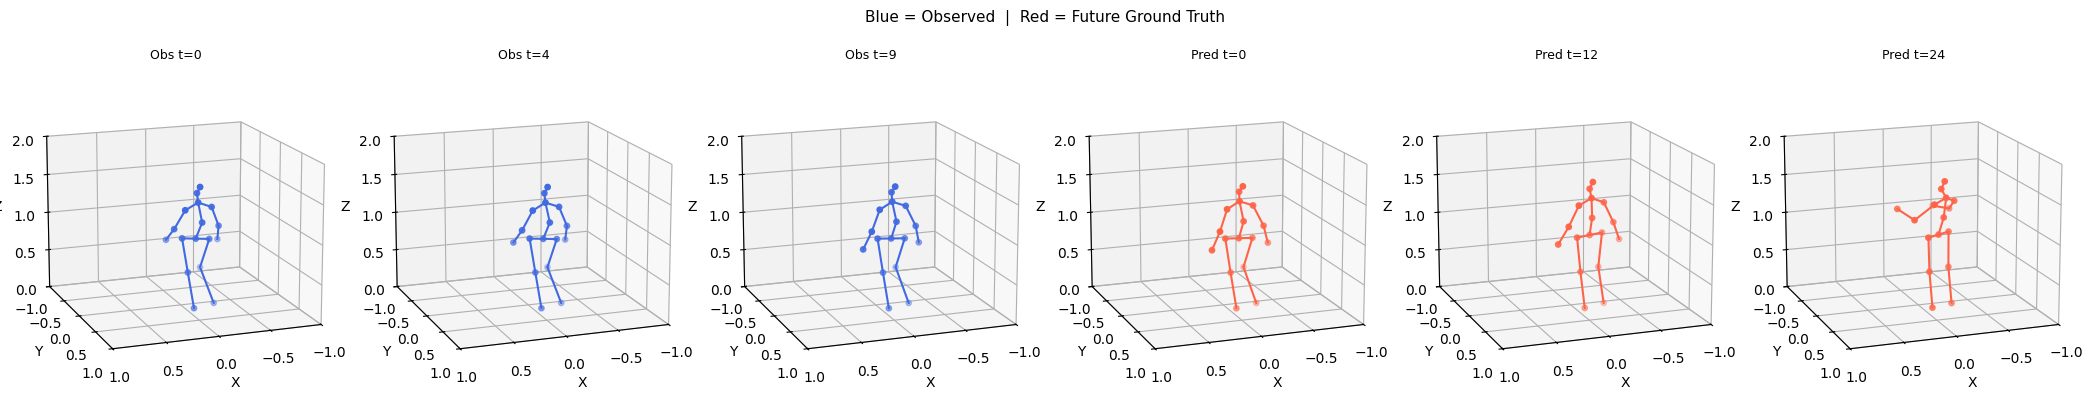

Saved: skeleton_viz.png


In [102]:
def visualize_sequence(seq_obs, seq_pred, edges, n_obs=3, n_pred=3):
    """
    seq_obs:  (10, 17, 3) tensor or numpy
    seq_pred: (25, 17, 3) tensor or numpy
    """
    if torch.is_tensor(seq_obs):
        seq_obs  = seq_obs.numpy()
        seq_pred = seq_pred.numpy()

    # Pick evenly spaced frames from each
    obs_idx  = np.linspace(0, len(seq_obs)-1,  n_obs,  dtype=int)
    pred_idx = np.linspace(0, len(seq_pred)-1, n_pred, dtype=int)

    n_total = n_obs + n_pred
    fig = plt.figure(figsize=(3.5 * n_total, 4))

    def plot_pose(ax, pose, color, title):
        ax.scatter(pose[:,0], pose[:,1], pose[:,2],
                   c=color, s=15, zorder=3)
        for (i, j) in edges:
            ax.plot([pose[i,0], pose[j,0]],
                    [pose[i,1], pose[j,1]],
                    [pose[i,2], pose[j,2]],
                    color=color, linewidth=1.5)
        ax.set_title(title, fontsize=9)
        ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
        ax.set_zlim([ 0, 2])
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.view_init(elev=15, azim=70)

    # Plot observed frames in blue
    for plot_i, frame_i in enumerate(obs_idx):
        ax = fig.add_subplot(1, n_total, plot_i+1, projection='3d')
        plot_pose(ax, seq_obs[frame_i], 'royalblue',
                  f'Obs t={frame_i}')

    # Plot predicted frames in red
    for plot_i, frame_i in enumerate(pred_idx):
        ax = fig.add_subplot(1, n_total, n_obs+plot_i+1, projection='3d')
        plot_pose(ax, seq_pred[frame_i], 'tomato',
                  f'Pred t={frame_i}')

    plt.suptitle('Blue = Observed  |  Red = Future Ground Truth',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('skeleton_viz.png', bbox_inches='tight', dpi=100)
    plt.show()
    print("Saved: skeleton_viz.png")

# Run it on the first sample
sample = train_dataset[0]
visualize_sequence(sample['observed'], sample['future'],
                   edges=SKELETON_EDGES_17)

In [103]:
import os
from getpass import getpass

In [104]:
token = getpass("Enter your GitHub token: ")
os.environ['GITHUB_TOKEN'] = token

Enter your GitHub token: ··········


In [116]:
!git clone https://{os.environ['GITHUB_TOKEN']}@github.com/GayuniBas2001/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture.git

fatal: destination path 'SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture' already exists and is not an empty directory.


In [106]:
# %cd 'SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture'

In [107]:
# !git remote set-url origin https://github.com/GayuniBas2001/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture.git

In [108]:
user_email = input("Enter your email: ")
user_name = input("Enter your name: ")

Enter your email: gayunibas@gmail.com
Enter your name: GayuniBas2001


In [118]:
!git config --global user.email "{user_email}"
!git config --global user.name "{user_name}"

In [110]:
!git pull

Already up to date.


In [111]:
import shutil

# Copy current notebook into repo
shutil.copy('/content/drive/MyDrive/L4 Research Resources/Environment_Set_Up.ipynb', '/content/HumanMAC/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture')

'/content/HumanMAC/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/Environment_Set_Up.ipynb'

In [112]:
!git log --oneline -n 3

bca4748 (HEAD -> main, origin/main, origin/HEAD) Update README.md
2a7fce7 Update README.md
72b5c03 Update README.md


In [117]:
!git ls-files

LICENSE
README.md
cfg/h36m.yml
cfg/humaneva.yml
config.py
data_loader/dataset.py
data_loader/dataset_h36m.py
data_loader/dataset_h36m_multimodal.py
data_loader/dataset_humaneva.py
data_loader/dataset_humaneva_multimodal.py
data_loader/skeleton.py
demos/control.gif
demos/pred.gif
demos/switch.gif
demos/zero_shot.gif
doc-CN/README.md
install.sh
main.py
models/diffusion.py
models/transformer.py
motion-retargeting/README.md
motion-retargeting/trans.py
motion-retargeting/vis-amass.py
motion-retargeting/vis-h36.py
motion-retargeting/vis-retar-h36.py
requirement.txt
utils/__init__.py
utils/demo_visualize.py
utils/evaluation.py
utils/logger.py
utils/metrics.py
utils/pose_gen.py
utils/script.py
utils/torch.py
utils/training.py
utils/util.py
utils/visualization.py


In [114]:
!git add Environment_Set_Up.ipynb
!git commit -m "Add notebook"
!git push origin main

fatal: pathspec 'Environment_Set_Up.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/
	data/
	skeleton_viz.png

nothing added to commit but untracked files present (use "git add" to track)
fatal: could not read Username for 'https://github.com': No such device or address


In [115]:
!pwd

/content/HumanMAC/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/SPaRTA-Spatially-Pruned-Affordance-aware-Transformer-Architecture/HumanMAC
